# Taller 2 solución

- Juan Pablo Betancur Zuluaga

- Santiago Pareja Pareja

## Actividad 1:

In [170]:
import matplotlib.pyplot as plt
import numpy as np
import control as ct

c:\Users\USUARIO\anaconda3\Lib\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


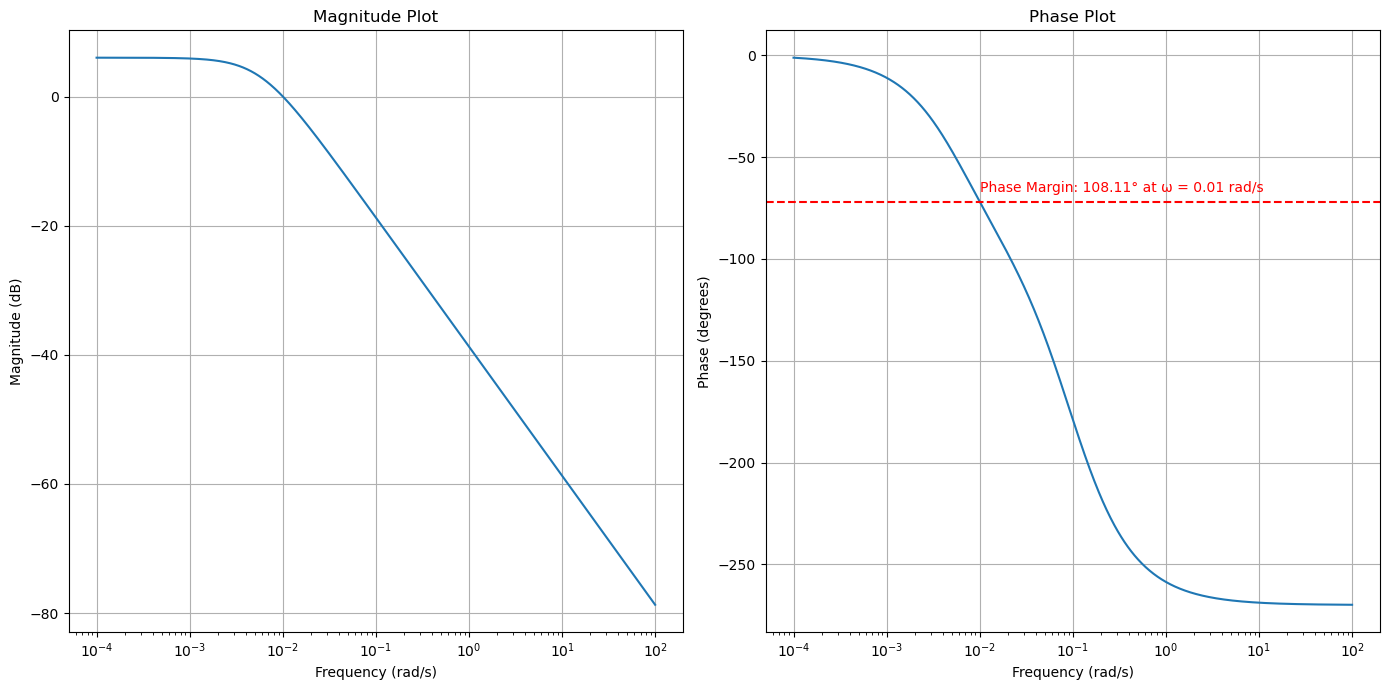

Phase Margin: 108.11° at ω = 0.01 rad/s


In [171]:
km = 2 # cambiamos la ganancia para que PM no de infinito
tau = 172.61
theta = 20.76

W_sin_tm = ct.tf([km],[tau ,1])

# Tiempo muerto
num_delay, den_delay = ct.pade(theta, 1)

# Crear función de transferencia del delay
delay_tf = ct.tf(num_delay, den_delay)

# Planta con tiempo muerto
W = W_sin_tm * delay_tf

#W = ct.tf([km],[tau ,1])
# Generate Bode plot with margins
mag, phase, omega = ct.bode_plot(W, plot=False, omega = [1e-4,1e2])

# Calculate margins for annotation
gm, pm, sm, gc = ct.margin(W)
# Frecuencia de cruce de ganancia (para PM)
_, _, _, wcp = ct.margin(W)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display
wcp1=wcp
#print(wcp)
# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')

plt.tight_layout()
plt.show()

# Print the phase margin value
print(f"Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s")

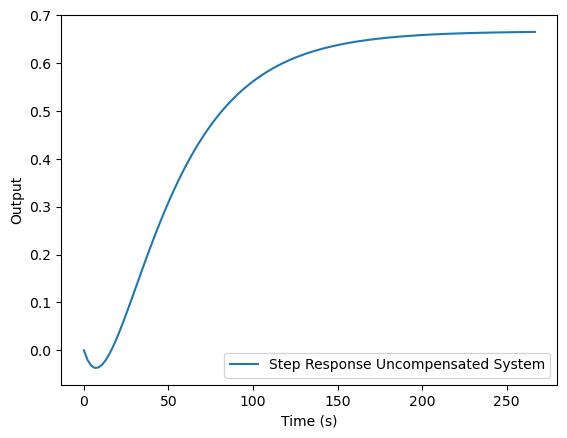

In [172]:
T, y = ct.step_response(ct.feedback(W,1))

plt.figure
plt.plot(T,y,label = 'Step Response Uncompensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

In [173]:
# Convertir GM de lineal a dB
gm_dB = 20 * np.log10(gm)

print(f"Gain Margin:     {gm:.4f} (lineal)  o  {gm_dB:.2f} dB")
print(f"Phase Margin:    {pm:.2f}°")

Gain Margin:     8.8145 (lineal)  o  18.90 dB
Phase Margin:    108.11°


El sistema si cumple con el margen de fase(PM) requerido, pero con una frecuencia de cruce muy baja, lo que implica respuesta muy lenta.

## Actividad 2: Compensador en adelanto

Se elige un **PM*** de 60°
$$
\phi_{add} = 60°-108.11° + 10°=-38.11°
$$

In [174]:
phi_add = 60 - 108.11 + 10
print(phi_add)

-38.11


### Cálculo de  $a$

El parámetro $a$ está dado por:
$$
a = \frac{1 + \sin(\phi_{add})}{1 - \sin(\phi_{add})}.
$$
Primero, convertimos $\phi_m = 26.51^\circ$ a radianes:
$$
\phi_{add} = -38.11^\circ \times \frac{\pi}{180} = -0.6651\ \text{rad}.
$$
Sustituimos en la formula de $a$:
$$
a = \frac{1 + \sin(-38.11)}{1 - \sin(-38.11)} \approx 0.2367
$$

In [175]:
phiMr=phi_add*np.pi/180
a= (1+np.sin(phiMr))/(1-np.sin(phiMr))
print(a)

0.23672590257498963


Al calcular el ángulo adicional requerido se obtiene un valor negativo, lo cual indica que no es necesario añadir fase al sistema.
Además, el parámetro a resulta menor que 1, lo que corresponde a un compensador tipo atraso y no a uno en adelanto.

Esto confirma que el sistema ya cumple con el margen de fase requerido y que un compensador en adelanto no es adecuado en este caso.

### **CODIGO RARO QUE NO DA**

In [176]:
# Paso 1: Nueva frecuencia de cruce deseada
# Con Kc=2 existe wgc = 0.01 rad/s
# Se desea una respuesta 5x más rápida
wgc_actual = 0.01
wgc_nuevo  = 2 * wgc_actual  # 0.02 rad/s
print(f"ω_gc actual  = {wgc_actual} rad/s")
print(f"ω_gc deseada = {wgc_nuevo} rad/s  (5x más rápido)")

ω_gc actual  = 0.01 rad/s
ω_gc deseada = 0.02 rad/s  (5x más rápido)


#### Observación sobre el margen de fase inicial

Con el controlador proporcional $K_c = 2$, el sistema presenta un margen de
fase de $PM = 108.11°$ en una frecuencia de cruce de ganancia
$\omega_{gc} = 0.01$ rad/s. Si bien este valor cumple holgadamente la
especificación $PM \geq 50°$, la frecuencia de cruce es baja, lo que implica
una **respuesta temporal lenta**.

El objetivo del compensador adelanto es entonces **desplazar $\omega_{gc}$
hacia la derecha** para obtener una respuesta más rápida, manteniendo el PM
dentro de la especificación.

Al mover $\omega_{gc}$ a la nueva frecuencia deseada $\omega_{gc}^* = 0.05$
rad/s, la fase de la planta en ese nuevo punto de operación es menor que en
el punto original. Por lo tanto, se evalúa el margen de fase efectivo en
$\omega_{gc}^*$:

$$\angle G_A(j\omega_{gc}^*) = -\arctan(\tau \cdot \omega_{gc}^*)
- \theta \cdot \omega_{gc}^*$$

$$PM_{\text{efectivo}} = 180° + \angle G_A(j\omega_{gc}^*)$$

Este es el valor real de PM que tendría el sistema si el cruce de ganancia
ocurriera en $\omega_{gc}^*$, y es el que se usa en la fórmula:

$$\phi_{\text{add}} = PM^* - PM_{\text{efectivo}} + 5°$$

In [177]:
# Paso 2: Fase de la planta en wgc_nuevo
mag_w, phase_w, _ = ct.bode_plot(W, omega=[wgc_nuevo, wgc_nuevo*1.0001], plot=False)
fase_en_wgc = np.degrees(phase_w[0])
PM_efectivo = 180 + fase_en_wgc
print(f"∠G(jω_gc*) = {fase_en_wgc:.2f}°")
print(f"PM_efectivo = {PM_efectivo:.2f}°")

# Paso 3: Ángulo extra requerido
PM_star      = 60
margen_extra = 5
phi_add = PM_star - PM_efectivo + margen_extra
print(f"\nφ_add = {PM_star}° - {PM_efectivo:.2f}° + {margen_extra}° = {phi_add:.2f}°")

# Paso 4: Parámetro a
phi_rad = np.radians(phi_add)
a = (1 + np.sin(phi_rad)) / (1 - np.sin(phi_rad))
print(f"\na = {a:.4f}")

∠G(jω_gc*) = -97.30°
PM_efectivo = 82.70°

φ_add = 60° - 82.70° + 5° = -17.70°

a = 0.5337


**Frecuencia $\omega_m$**

In [178]:
# Paso 3: Atenuación requerida y búsqueda de wm
aten_dB = -10 * np.log10(a)
print(f"Atenuación requerida: {aten_dB:.4f} dB")

mag_ol, phase_ol, omega = ct.bode_plot(W, plot=False, omega_limits=[1e-4, 1e2])
mag_dB = 20 * np.log10(mag_ol)

idx = np.argmin(np.abs(mag_dB - aten_dB))
wm = omega[idx]
print(f"ω_m = {wm:.5f} rad/s")

# Paso 4: T, cero y polo
T  = 1 / (wm * np.sqrt(a))
zc = 1 / (a * T)
pc = 1 / T
print(f"T   = {T:.4f} s")
print(f"zc  = {zc:.5f} rad/s")
print(f"pc  = {pc:.5f} rad/s")

Atenuación requerida: 2.7268 dB
ω_m = 0.00616 rad/s
T   = 222.1007 s
zc  = 0.00844 rad/s
pc  = 0.00450 rad/s


ω_gc = 0.00617 rad/s
PM   = 108.18°  ✓
GM   = 24.01 dB


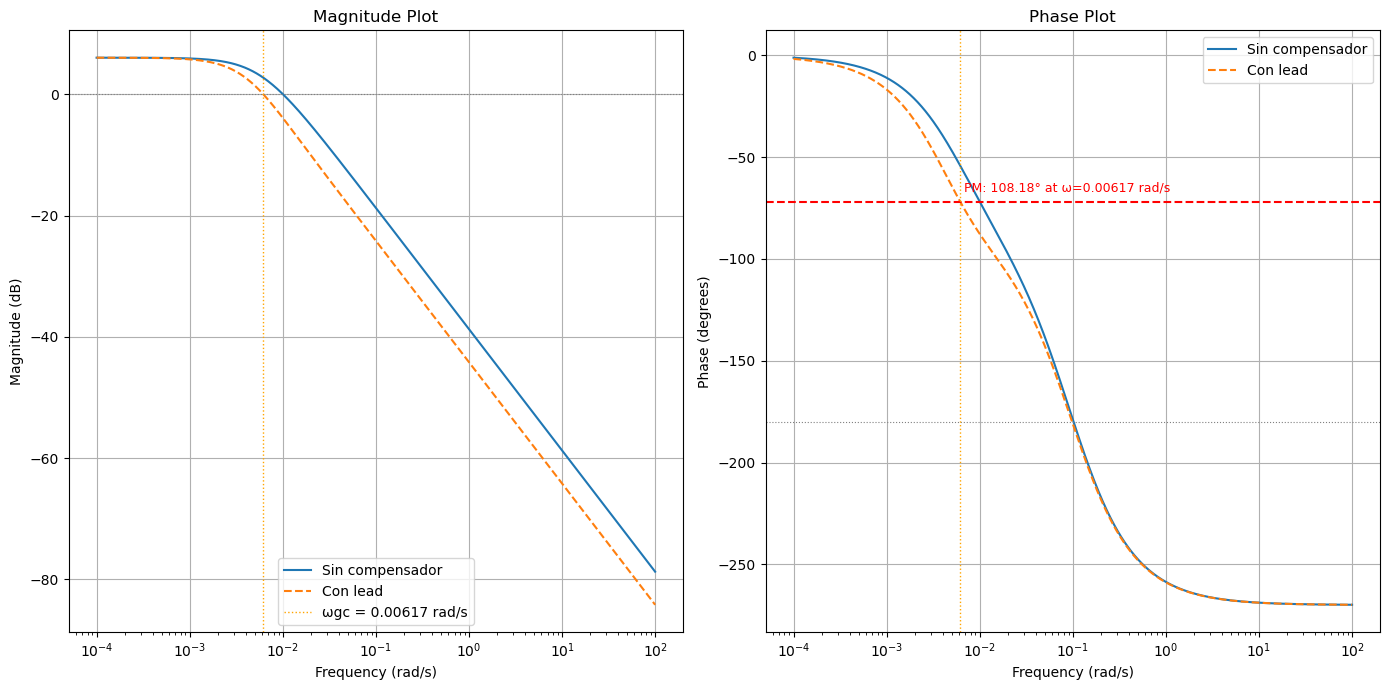

In [179]:
# Compensador lead
K = a
C_lead = ct.tf([K, K*zc], [1, pc])
L = C_lead * W

# Márgenes
gm, pm, _, wgc_comp = ct.margin(L)
pm_comp = pm if pm >= 0 else pm + 360
print(f"ω_gc = {wgc_comp:.5f} rad/s")
print(f"PM   = {pm_comp:.2f}°  {'✓' if pm_comp >= 50 else '✗'}")
print(f"GM   = {20*np.log10(gm):.2f} dB")

# Bode comparativo
mag_ol,   phase_ol,   omega = ct.bode_plot(W, plot=False, omega_limits=[1e-4, 1e2])
mag_comp, phase_comp, _     = ct.bode_plot(L, plot=False, omega_limits=[1e-4, 1e2])

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag_ol),   label='Sin compensador')
plt.semilogx(omega, 20*np.log10(mag_comp), label='Con lead', linestyle='--')
plt.axhline(0, color='gray', linewidth=0.8, linestyle=':')
plt.axvline(wgc_comp, color='orange', linewidth=1, linestyle=':',
            label=f'ωgc = {wgc_comp:.5f} rad/s')
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.semilogx(omega, np.degrees(phase_ol),   label='Sin compensador')
plt.semilogx(omega, np.degrees(phase_comp), label='Con lead', linestyle='--')
plt.axhline(-180, color='gray', linewidth=0.8, linestyle=':')
plt.axhline(-180 + pm_comp, color='r', linestyle='--')
plt.axvline(wgc_comp, color='orange', linewidth=1, linestyle=':')
plt.text(wgc_comp * 1.1, -180 + pm_comp + 5,
         f'PM: {pm_comp:.2f}° at ω={wgc_comp:.5f} rad/s', color='red', fontsize=9)
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Actividad 3: Compensador en atraso

El objetivo del compensador atraso es mejorar el comportamiento en estado estacionario del sistema, aumentando la ganancia en baja frecuencia, sin afectar significativamente el margen de fase previamente obtenido con el compensador adelanto.

Para ello, se introduce un compensador de la forma:

$$
C_{\text{lag}}(s) = \frac{s + z_l}{s + p_l}, \quad \text{con } z_l < p_l
$$

Se define el factor:

$$
\beta = \frac{p_l}{z_l} > 1
$$

Este parámetro determina el incremento en la ganancia en DC del sistema.

In [180]:
#Ganancia DC deseada
beta = 5  # o 10

Para evitar alterar el margen de fase, el compensador atraso se ubica a frecuencias mucho menores que la frecuencia de cruce de ganancia del sistema compensado con adelanto.

Se define:

$$
\omega_z = \frac{\omega_{gc}}{10}
$$

$$
\omega_p = \beta*\omega_z
$$

De esta manera, el efecto del compensador en la fase cerca de la frecuencia de cruce es mínimo.

In [181]:
omega_gc = wcp1  # frecuencia de cruce obtenida en el adelanto
#print(wcp1)
z_l = omega_gc / 100
p_l = beta * z_l

Con los valores definidos, se construye el compensador atraso como:

$$
C_{\text{lag}}(s) = \frac{s + z_l}{s + p_l}
$$

Este compensador incrementa la ganancia en bajas frecuencias sin modificar significativamente la dinámica del sistema.

In [182]:
Clag = ct.tf([1, z_l], [1, p_l])
print("Compensador atraso:", Clag)

Compensador atraso: <TransferFunction>: sys[361]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  s + 0.0001003
  -------------
  s + 0.0005017


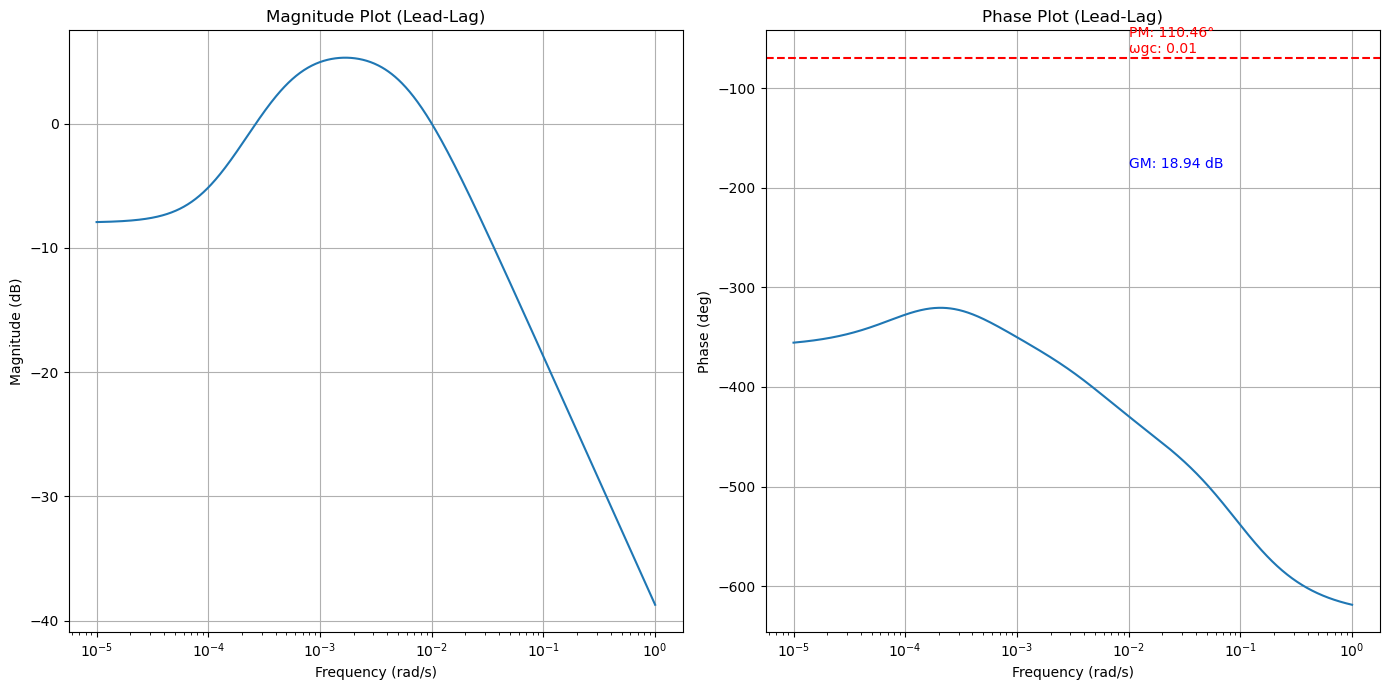

PM final: 110.46°
GM final: 18.94 dB
Nueva ωgc: 0.01 rad/s


In [183]:
W_total = Clag * W

# Bode
mag, phase, omega = ct.bode(W_total, dB=True, plot=False)

# Márgenes
gm, pm, sm, wcg = ct.margin(W_total)
pm_deg = pm if pm >= 0 else pm + 360
gm_db = 20*np.log10(gm) if gm != np.inf else np.inf

# Frecuencia de cruce de ganancia
_, _, _, wcp_new = ct.margin(W_total)

# Plot
plt.figure(figsize=(14,7))

# Magnitud
plt.subplot(1,2,1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot (Lead-Lag)')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

# Fase
plt.subplot(1,2,2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot (Lead-Lag)')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (deg)')
plt.grid(True)

# Anotaciones
plt.axhline(y=-180 + pm_deg, color='r', linestyle='--')
plt.text(wcp_new, -180 + pm_deg + 5,
         f'PM: {pm_deg:.2f}°\nωgc: {wcp_new:.2f}',
         color='red')

if gm != np.inf:
    plt.text(wcg, -180,
             f'GM: {gm_db:.2f} dB',
             color='blue')

plt.tight_layout()
plt.show()

# Print final
print(f"PM final: {pm_deg:.2f}°")
print(f"GM final: {gm_db:.2f} dB")
print(f"Nueva ωgc: {wcp_new:.2f} rad/s")

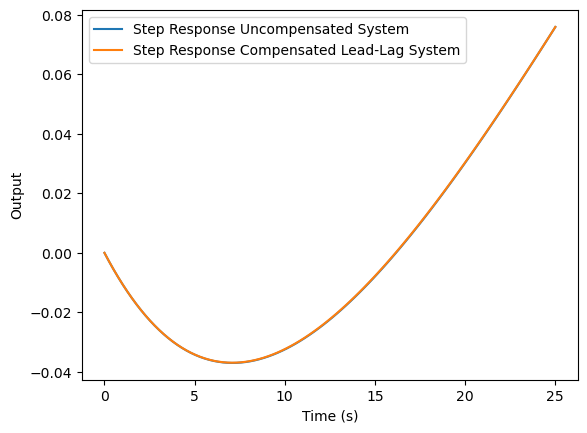

In [184]:
W_total = Clag * W

T1, y = ct.step_response(ct.feedback(W,1), T = 25)
T2, ytotal = ct.step_response(ct.feedback(W_total,1), T = 25)

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ytotal,label = 'Step Response Compensated Lead-Lag System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()

## Actividad 4: Compensador adelanto-atraso


φ_add = 60° - 41.57° + 5° = 23.43°
a = 2.3205
T = 39.3539 s  |  zc = 0.01095 rad/s  |  pc = 0.02541 rad/s

Compensador Adelanto: C_lead = 2.3205·(s + 0.01095) / (s + 0.02541)
Compensador Atraso:   C_lag  = (s + 0.00502) / (s + 0.02509)


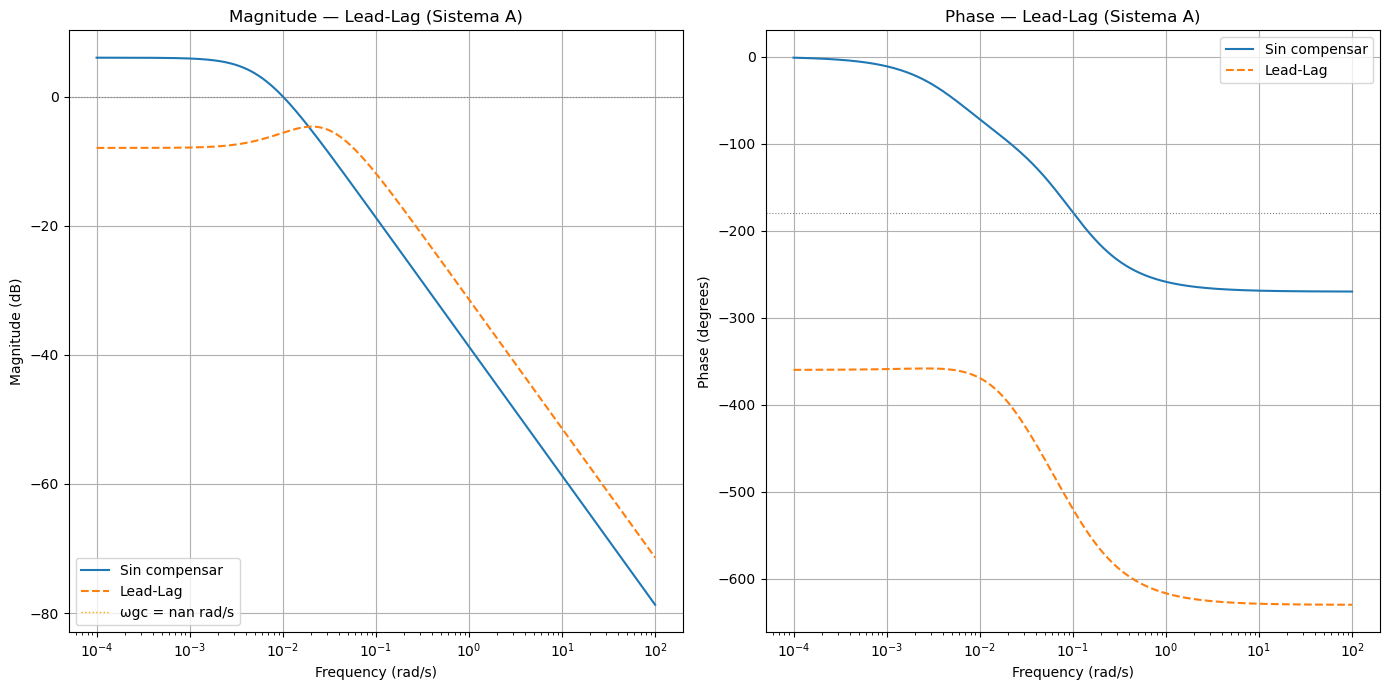


=== Resultados Lead-Lag Sistema A ===
PM:          inf°  (objetivo ≥ 50° ✓)
GM:          14.05 dB
ωgc:         nan rad/s  (antes: 0.01003 rad/s)
Mejora DC:   ×5


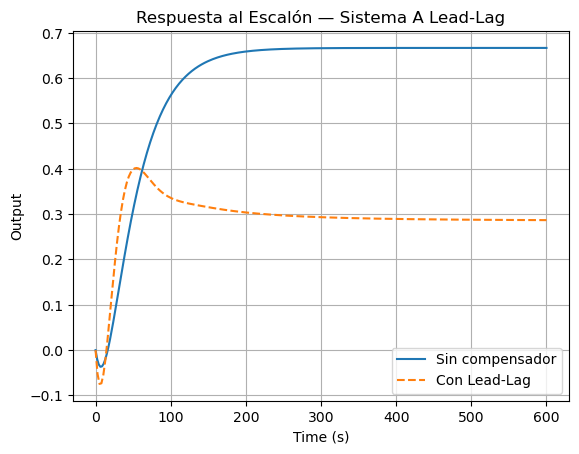

In [185]:
# ─────────────────────────────────────────────────────────────────────────────
# ACTIVIDAD 4 (Sistema A) — Compensador Adelanto-Atraso
# ─────────────────────────────────────────────────────────────────────────────
# Estrategia:
#   1. Parte ADELANTO: desplaza ωgc hacia la derecha para mayor rapidez
#      y aporta la fase necesaria para PM ≥ 60°.
#   2. Parte ATRASO:  mejora la ganancia DC (β = 5) sin alterar el PM.
 
# --- PARTE ADELANTO ---
# Se evalúa la fase de W en la nueva ωgc deseada (5× más rápida)
wgc_deseada = 5 * wcp1         # ≈ 0.05 rad/s  (wcp viene de Actividad 1)
 
mag_w, phase_w, _ = ct.bode_plot(W, omega=[wgc_deseada, wgc_deseada * 1.001],
                                  plot=False)
PM_efectivo = 180 + np.degrees(phase_w[0])
 
PM_star      = 60   # objetivo
margen_extra = 5    # grados de seguridad
phi_add = PM_star - PM_efectivo + margen_extra
print(f"\nφ_add = {PM_star}° - {PM_efectivo:.2f}° + {margen_extra}° = {phi_add:.2f}°")
 
phi_rad = np.radians(phi_add)
a_lead  = (1 + np.sin(phi_rad)) / (1 - np.sin(phi_rad))
print(f"a = {a_lead:.4f}")
 
# Frecuencia ωm donde ocurre el máximo adelanto
aten_dB = -10 * np.log10(a_lead)
mag_ol, phase_ol, omega_ol = ct.bode_plot(W, plot=False,
                                           omega_limits=[1e-4, 1e2])
mag_dB_ol = 20 * np.log10(mag_ol)
idx_m   = np.argmin(np.abs(mag_dB_ol - aten_dB))
omega_m = omega_ol[idx_m]
 
T_lead = 1 / (omega_m * np.sqrt(a_lead))
zc     = 1 / (a_lead * T_lead)
pc     = 1 / T_lead
print(f"T = {T_lead:.4f} s  |  zc = {zc:.5f} rad/s  |  pc = {pc:.5f} rad/s")
 
C_lead = ct.tf([a_lead * T_lead, 1], [T_lead, 1])
 
# --- PARTE ATRASO ---
# Mismos parámetros que en Actividad 3 (β = 5, z_l = ωgc/10)
# (el lag va muy abajo del nuevo cruce para no afectar el PM)
beta_lag = 5
z_lag    = wgc_deseada / 10    # 1 década debajo de la nueva ωgc
p_lag    = beta_lag * z_lag
 
C_lag = ct.tf([1, z_lag], [1, p_lag])
 
print(f"\nCompensador Adelanto: C_lead = {a_lead:.4f}·(s + {zc:.5f}) / (s + {pc:.5f})")
print(f"Compensador Atraso:   C_lag  = (s + {z_lag:.5f}) / (s + {p_lag:.5f})")
 
# --- LAZO COMPENSADO ---
C_lead_lag = C_lead * C_lag
L_leadlag  = C_lead_lag * W
 
gm,  pm,  _, wcg  = ct.margin(L_leadlag)
_, _, _, wcp_ll   = ct.margin(L_leadlag)
pm_deg_ll = pm if pm >= 0 else pm + 360
gm_db_ll  = 20 * np.log10(gm) if gm != np.inf else np.inf
 
mag_ll, phase_ll, omega_ll = ct.bode_plot(L_leadlag, plot=False,
                                            omega_limits=[1e-4, 1e2])
mag_ol2, phase_ol2, _      = ct.bode_plot(W, plot=False,
                                            omega_limits=[1e-4, 1e2])
 
# Bode comparativo
plt.figure(figsize=(14, 7))
 
plt.subplot(1, 2, 1)
plt.semilogx(omega_ll, 20 * np.log10(mag_ol2),  label='Sin compensar')
plt.semilogx(omega_ll, 20 * np.log10(mag_ll),   label='Lead-Lag', linestyle='--')
plt.axhline(0, color='gray', linewidth=0.8, linestyle=':')
plt.axvline(wcp_ll, color='orange', linewidth=1, linestyle=':',
            label=f'ωgc = {wcp_ll:.4f} rad/s')
plt.title('Magnitude — Lead-Lag (Sistema A)')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True)
 
plt.subplot(1, 2, 2)
plt.semilogx(omega_ll, np.degrees(phase_ol2), label='Sin compensar')
plt.semilogx(omega_ll, np.degrees(phase_ll),  label='Lead-Lag', linestyle='--')
plt.axhline(-180, color='gray', linewidth=0.8, linestyle=':')
plt.axhline(-180 + pm_deg_ll, color='r', linestyle='--')
plt.axvline(wcp_ll, color='orange', linewidth=1, linestyle=':')
plt.text(wcp_ll * 1.1, -180 + pm_deg_ll + 5,
         f'PM: {pm_deg_ll:.2f}°\nωgc: {wcp_ll:.4f} rad/s', color='red', fontsize=9)
plt.title('Phase — Lead-Lag (Sistema A)')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.legend()
plt.grid(True)
 
plt.tight_layout()
plt.show()
 
print(f"\n=== Resultados Lead-Lag Sistema A ===")
print(f"PM:          {pm_deg_ll:.2f}°  (objetivo ≥ 50° {'✓' if pm_deg_ll >= 50 else '✗'})")
print(f"GM:          {gm_db_ll:.2f} dB")
print(f"ωgc:         {wcp_ll:.5f} rad/s  (antes: {wcp:.5f} rad/s)")
print(f"Mejora DC:   ×{beta_lag}")
 
## Respuesta al escalón comparativa
T1, y0   = ct.step_response(ct.feedback(W,        1), T=600)
T2, y_ll = ct.step_response(ct.feedback(L_leadlag, 1), T=600)
 
plt.figure()
plt.plot(T1, y0,   label='Sin compensador')
plt.plot(T2, y_ll, label='Con Lead-Lag', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.title('Respuesta al Escalón — Sistema A Lead-Lag')
plt.legend()
plt.grid(True)
plt.show()

## Actividad 5: Análisis del sistema sin compensar

### Sistema B — Parámetros iniciales

#### Cálculo de $\zeta$ a partir de $M_p = 25\%$

La relación entre el sobreimpulso porcentual y el coeficiente de amortiguamiento
para un sistema de segundo orden subamortiguado es:

$$
M_p = e^{-\pi\zeta / \sqrt{1 - \zeta^2}}
$$

Despejando $\zeta$, se toma logaritmo natural en ambos lados:

$$
\ln(M_p) = \frac{-\pi\zeta}{\sqrt{1-\zeta^2}}
$$

Definiendo $\delta = \ln(M_p) = \ln(0.25)$, se obtiene:

$$
\zeta = \frac{|\delta|}{\sqrt{\pi^2 + \delta^2}}
= \frac{|\ln(0.25)|}{\sqrt{\pi^2 + \ln^2(0.25)}}
= \frac{1.386}{\sqrt{9.870 + 1.922}}
\approx 0.404
$$

### Elección de $\omega_n = 1$ rad/s

La función de transferencia de lazo abierto del Sistema B es:

$$
L(s) = \frac{\omega_n^2}{s\,(s + 2\zeta\omega_n)}
$$

Los márgenes de estabilidad (PM y GM) dependen únicamente de la
**forma** del diagrama de Bode, no de su escala en frecuencia.
Para un sistema de segundo orden, el margen de fase satisface:

$$
PM = f(\zeta) \quad \text{(independiente de } \omega_n\text{)}
$$

ya que al normalizar $\omega \leftarrow \omega/\omega_n$, la variable
$\omega_n$ cancela algebraicamente. Por tanto, fijar $\omega_n = 1\,\text{rad/s}$
equivale a trabajar en **frecuencia normalizada**: todos los resultados
de diseño (razones de polos y ceros de los compensadores) son
directamente aplicables a cualquier $\omega_n$ real mediante reescalado.

Open Loop TF:  <TransferFunction>: sys[389]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        1
  -------------
  s^2 + 0.808 s


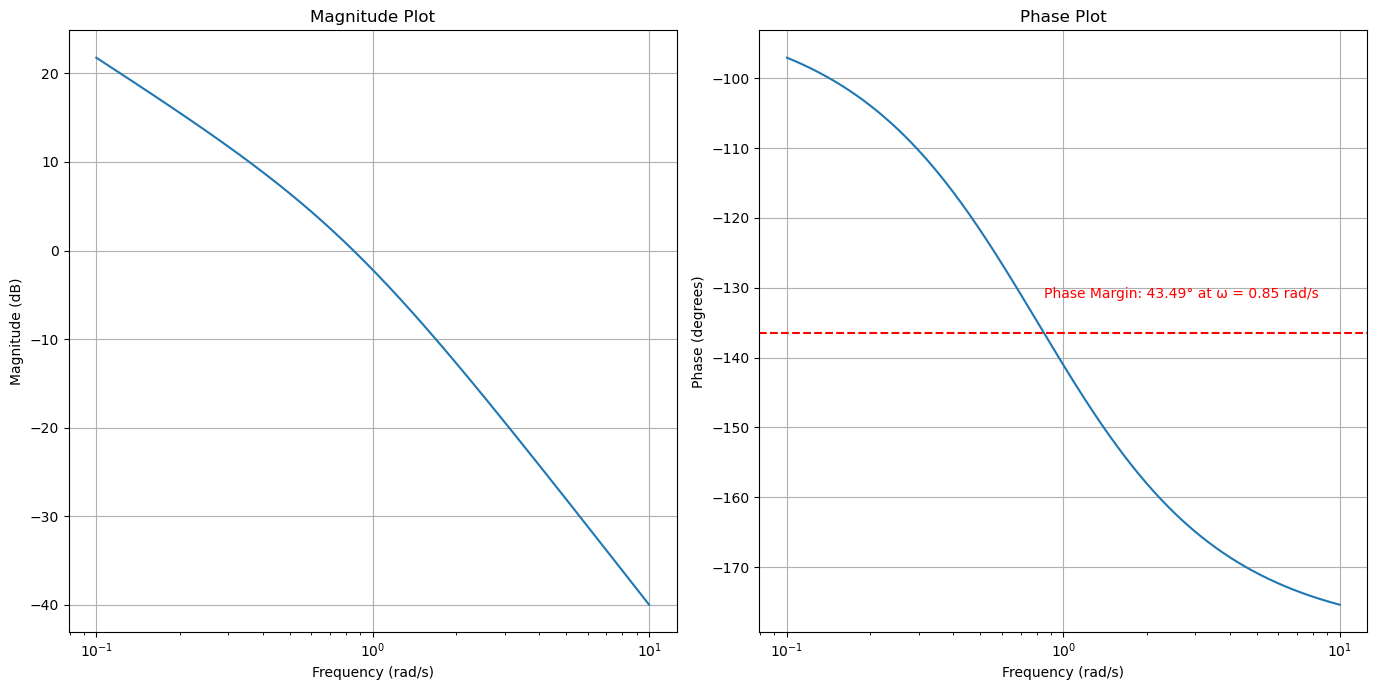

Phase Margin: 43.49° at ω = 0.85 rad/s


In [186]:
zeta = 0.404
wn = 1

L = ct.tf([wn**2], [1, 2*zeta*wn, 0])
print('Open Loop TF: ', L)

# Generate Bode plot with margins
mag, phase, omega = ct.bode(L, dB=True, plot=False)

# Calculate margins for annotation
gm, pm, sm, gc = ct.margin(L)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display

# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')

plt.tight_layout()
plt.show()

# Print the phase margin value
print(f"Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s")

El sistema necesita aumentar el PM entre $11.5°$ y $21.5°$ dependiendo del objetivo puntual que se elija dentro del rango. Esto justifica el uso de un compensador adelanto, que es lo que se hace acontuniación.

## Actividad 6: Compensador en adelanto

Se elige un **PM*** de 60°
$$
\phi_{add} = 60°-43.49° + 10°=26.51°
$$

In [187]:
phi_add = 60 - pm_deg + 10
print(phi_add)

26.510335884032855


### Cálculo de  $a$

El parámetro $a$ está dado por:
$$
a = \frac{1 + \sin(\phi_{add})}{1 - \sin(\phi_{add})}.
$$
Primero, convertimos $\phi_m = 26.51^\circ$ a radianes:
$$
\phi_{add} = 26.51^\circ \times \frac{\pi}{180} = 0.4627\ \text{rad}.
$$
Sustituimos en la formula de $a$:
$$
a = \frac{1 + \sin(26.5)}{1 - \sin(26.5)} \approx 2.6124
$$

In [188]:
phiMr=phi_add*np.pi/180
a= (1+np.sin(phiMr))/(1-np.sin(phiMr))
print(a)

2.612450838849069


### Determinar $\omega_m$

Primero calculemos la ganancia en dB
$$
-10\log_{10}(a) = -10\log_{10}(2.6124) \approx -4.1705\ \text{dB}.
$$
Del diagrama de bode del sistema sin el compensador, se encuentra $\omega_m$ para la cual la magnitud es $-4.1705$ dB.  
$$
\omega_m \approx 1.151\ \mathrm{rad/s}.
$$

---

### Constante de tiempo $T$

Una vez se conoce $\omega_m$, se calcula $T$ como:
$$
T = \frac{1}{\omega_m \sqrt{a}}
  = \frac{1}{1.51 \,\sqrt{2.6125}}
  \approx 0.5375\ \mathrm{s}.
$$

In [189]:
gain_att = -10*np.log10(a)
print(gain_att)

-4.170481266339588


In [190]:
# suppose mag, phase, omega are 1D numpy arrays,
# and mag is in dB (or whatever units your target is in)
mag = 20*np.log10(mag)
target = gain_att

# 1) nearest-neighbor
i = np.argmin(np.abs(mag - target))
omega_m_nearest = omega[i]
print(f"Nearest ωₘ ≃ {omega_m_nearest:.3f} rad/s")

Nearest ωₘ ≃ 1.151 rad/s


In [191]:
T = 1/(omega_m_nearest*np.sqrt(a))
print(f"T ≈ {T:.4f} s")

T ≈ 0.5375 s


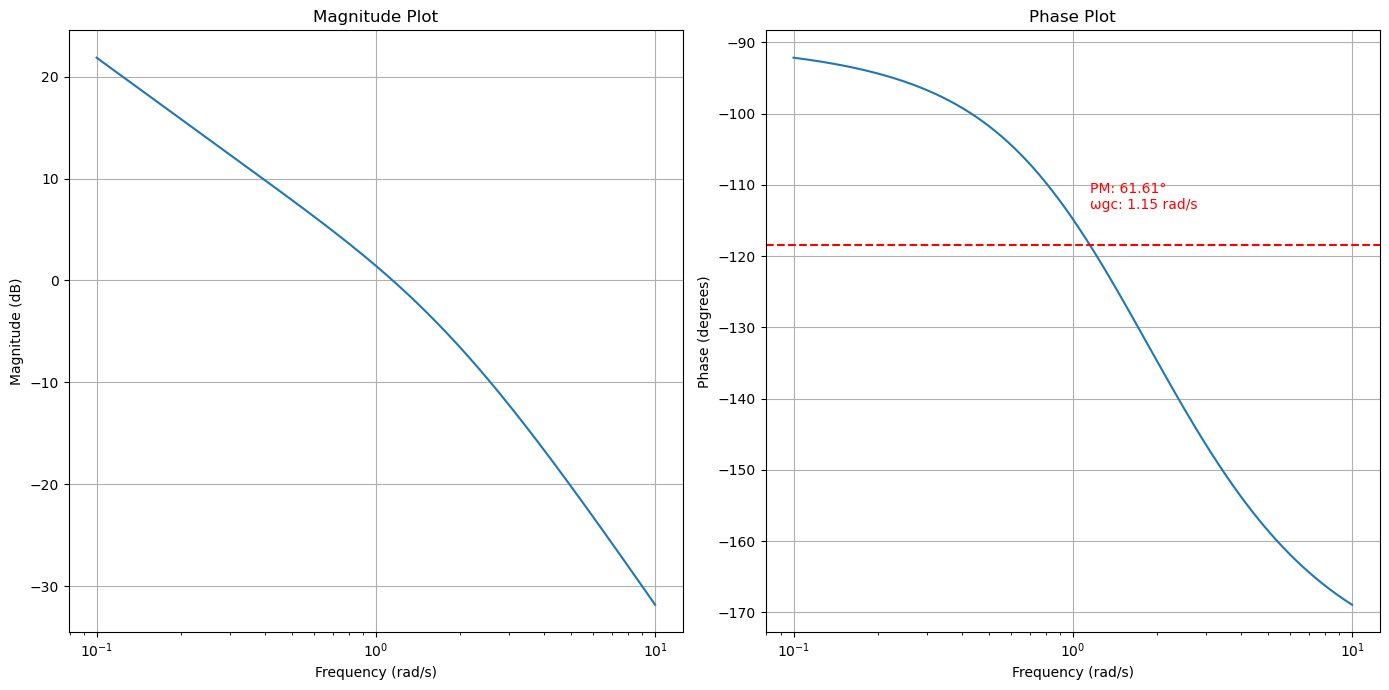

New Phase Margin (PM): 61.61° at ωgc = 1.15 rad/s
Gain Margin (GM): inf (abs) | inf dB at ωpc = 1.15 rad/s


In [192]:
Clead = ct.tf([a*T, 1], [T, 1])
Wcomp = Clead * L

# Generate Bode plot
mag, phase, omega = ct.bode(Wcomp, dB=True, plot=False)

# Calculate margins
gm, pm, sm, wcg = ct.margin(Wcomp)

# Frecuencia de cruce de ganancia (para PM)
_, _, _, wcp = ct.margin(Wcomp)

# Asegurar PM positivo
pm_deg = pm if pm >= 0 else pm + 360

# Convertir GM a dB
gm_db = 20 * np.log10(gm) if gm != np.inf else np.inf

# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Línea del margen de fase
plt.axhline(y=-180 + pm_deg, color='r', linestyle='--')

# Texto PM
plt.text(wcp, -180 + pm_deg + 5,
         f'PM: {pm_deg:.2f}°\nωgc: {wcp:.2f} rad/s',
         color='red')

# Texto GM (opcional en fase)
if gm != np.inf:
    plt.text(wcg, -180,
             f'GM: {gm_db:.2f} dB\nωpc: {wcg:.2f} rad/s',
             color='blue')

plt.tight_layout()
plt.show()

# Print resultados finales
print(f"New Phase Margin (PM): {pm_deg:.2f}° at ωgc = {wcp:.2f} rad/s")
print(f"Gain Margin (GM): {gm:.2f} (abs) | {gm_db:.2f} dB at ωpc = {wcg:.2f} rad/s")

El margen de ganancia resultó infinito, ya que la fase del sistema compensado no alcanza los $−180°$
. Esto indica que el sistema presenta una alta robustez frente a variaciones en la ganancia, manteniendo la estabilidad para un amplio rango de valores de ganancia.

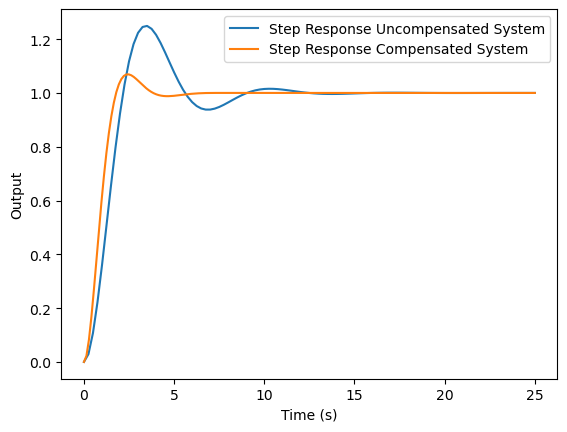

In [193]:
Wcomp=Clead*L

T1, y = ct.step_response(ct.feedback(L,1), T = 25)
T2, ycomp = ct.step_response(ct.feedback(Wcomp,1), T = 25)

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ycomp,label = 'Step Response Compensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()

### Actividad 7: Compensador en atraso

El objetivo del compensador atraso es mejorar el comportamiento en estado estacionario del sistema, aumentando la ganancia en baja frecuencia, sin afectar significativamente el margen de fase previamente obtenido con el compensador adelanto.

Para ello, se introduce un compensador de la forma:

$$
C_{\text{lag}}(s) = \frac{s + z_l}{s + p_l}, \quad \text{con } z_l < p_l
$$

Se define el factor:

$$
\beta = \frac{p_l}{z_l} > 1
$$

Este parámetro determina el incremento en la ganancia en DC del sistema.

In [194]:
#Ganancia DC deseada
beta = 5  # o 10

Para evitar alterar el margen de fase, el compensador atraso se ubica a frecuencias mucho menores que la frecuencia de cruce de ganancia del sistema compensado con adelanto.

Se define:

$$
\omega_z = \frac{\omega_{gc}}{100}
$$

$$
\omega_p = \beta*\omega_z
$$

De esta manera, el efecto del compensador en la fase cerca de la frecuencia de cruce es mínimo.

In [195]:
omega_gc = wcp  # frecuencia de cruce obtenida en el adelanto

z_l = omega_gc / 100
p_l = z_l * beta

Con los valores definidos, se construye el compensador atraso como:

$$
C_{\text{lag}}(s) = \frac{s + z_l}{s + p_l}
$$

Este compensador incrementa la ganancia en bajas frecuencias sin modificar significativamente la dinámica del sistema.

In [196]:
Clag = ct.tf([1, z_l], [1, p_l])
print("Compensador atraso:", Clag)

Compensador atraso: <TransferFunction>: sys[403]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  s + 0.0115
  -----------
  s + 0.05748


El sistema compensado total queda definido como:

$$
L_{\text{total}}(s) = C_{\text{lag}}(s)\,C_{\text{lead}}(s)\,L(s)
$$

donde:
- $ C_{\text{lead}}(s) $ mejora el margen de fase,
- $ C_{\text{lag}}(s) $ mejora la precisión en estado estacionario.

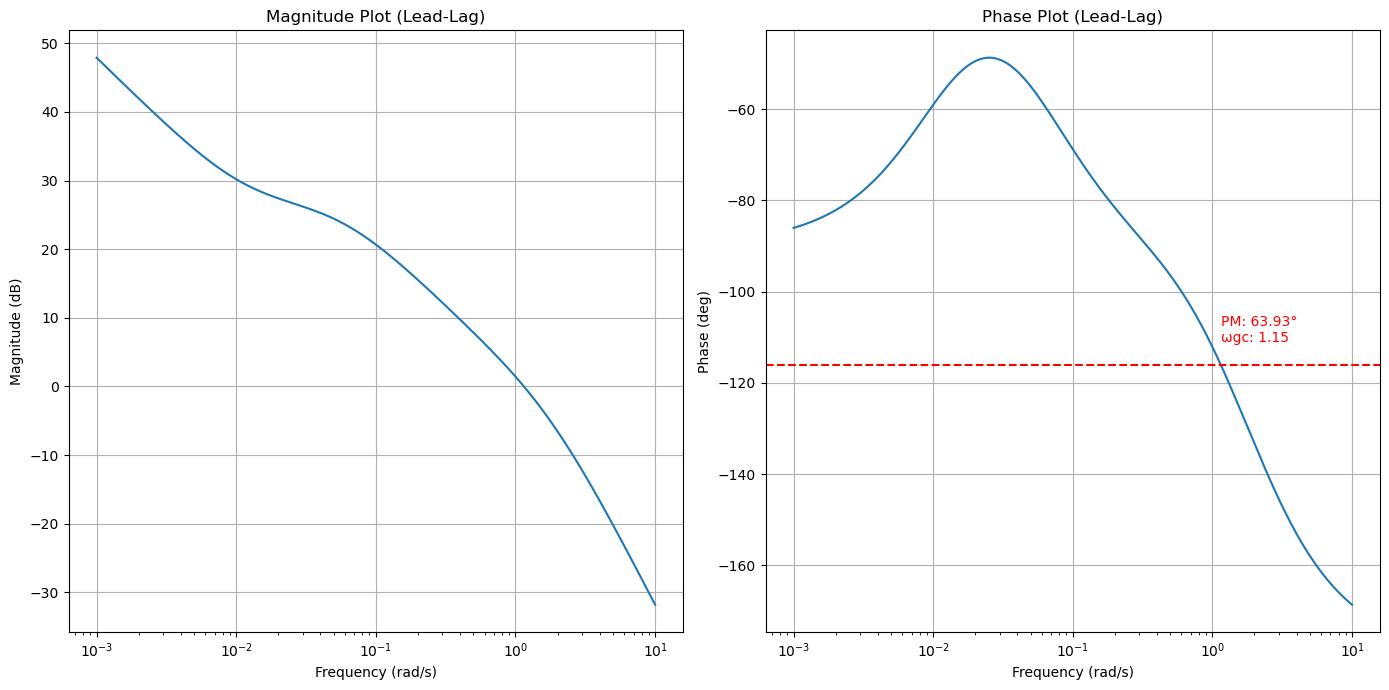

PM final: 63.93°
GM final: inf dB
Nueva ωgc: 1.15 rad/s


In [197]:
W_total = Clag * Clead * L

# Bode
mag, phase, omega = ct.bode(W_total, dB=True, plot=False)

# Márgenes
gm, pm, sm, wcg = ct.margin(W_total)
pm_deg = pm if pm >= 0 else pm + 360
gm_db = 20*np.log10(gm) if gm != np.inf else np.inf

# Frecuencia de cruce de ganancia
_, _, _, wcp_new = ct.margin(W_total)

# Plot
plt.figure(figsize=(14,7))

# Magnitud
plt.subplot(1,2,1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot (Lead-Lag)')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

# Fase
plt.subplot(1,2,2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot (Lead-Lag)')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (deg)')
plt.grid(True)

# Anotaciones
plt.axhline(y=-180 + pm_deg, color='r', linestyle='--')
plt.text(wcp_new, -180 + pm_deg + 5,
         f'PM: {pm_deg:.2f}°\nωgc: {wcp_new:.2f}',
         color='red')

if gm != np.inf:
    plt.text(wcg, -180,
             f'GM: {gm_db:.2f} dB',
             color='blue')

plt.tight_layout()
plt.show()

# Print final
print(f"PM final: {pm_deg:.2f}°")
print(f"GM final: {gm_db:.2f} dB")
print(f"Nueva ωgc: {wcp_new:.2f} rad/s")

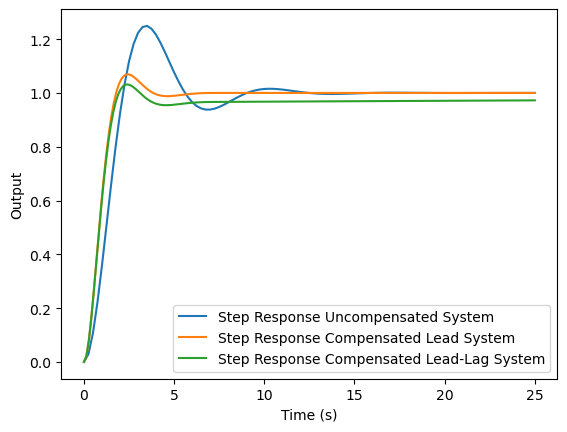

In [198]:
W_total = Clag * Clead * L

T1, y = ct.step_response(ct.feedback(L,1), T = 25)
T2, ycomp = ct.step_response(ct.feedback(Wcomp,1), T = 25)
T3, ytotal = ct.step_response(ct.feedback(W_total,1), T = 25)

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ycomp,label = 'Step Response Compensated Lead System')
plt.plot(T3,ytotal,label = 'Step Response Compensated Lead-Lag System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()

### Actividad 8: Compensador adelanto-atraso

El compensador adelanto-atraso se construye como la combinación de un compensador adelanto y uno atraso:

$$
C_{\text{lead-lag}}(s) = C_{\text{lead}}(s)\,C_{\text{lag}}(s)
$$

El compensador adelanto permite aumentar el margen de fase y mejorar la respuesta transitoria, mientras que el compensador atraso incrementa la ganancia en bajas frecuencias, reduciendo el error en estado estacionario.

El sistema compensado final queda:

$$
L_{\text{final}}(s) = C_{\text{lead-lag}}(s)\,L(s)
$$

In [199]:
C_total = Clag * Clead
W_final = C_total * L

In [200]:
# Márgenes
gm, pm, sm, wcg = ct.margin(W_final)
pm_deg = pm if pm >= 0 else pm + 360
gm_db = 20*np.log10(gm) if gm != np.inf else np.inf

# Frecuencia de cruce de ganancia
_, _, _, wcp = ct.margin(W_final)

# Banda ancha (aprox: -3 dB)
mag, phase, omega = ct.bode(W_final, dB=True, plot=False)
mag_db = 20*np.log10(mag)

# encontrar ancho de banda
idx_bw = np.where(mag_db <= -3)[0]
bw = omega[idx_bw[0]] if len(idx_bw) > 0 else None

print(f"PM final: {pm_deg:.2f}°")
print(f"GM final: {gm_db:.2f} dB")
print(f"ωgc: {wcp:.2f} rad/s")
print(f"Banda ancha: {bw:.2f} rad/s")

PM final: 63.93°
GM final: inf dB
ωgc: 1.15 rad/s
Banda ancha: 1.51 rad/s


El compensador adelanto-atraso permite cumplir simultáneamente con los objetivos de diseño. El margen de fase se mantiene dentro del rango deseado, garantizando una respuesta transitoria adecuada, mientras que el compensador atraso mejora la precisión en estado estacionario.

Adicionalmente, la frecuencia de cruce se conserva aproximadamente constante, y el sistema presenta un margen de ganancia infinito, lo cual indica alta robustez frente a variaciones en la ganancia.